In [69]:
# Suppress noisy TensorFlow logs before importing
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

#  Third party imports
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import tensorflow as tf
import itertools
import time

#from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score, log_loss, accuracy_score, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
#from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder, MinMaxScaler
from sklearn.utils.class_weight import compute_sample_weight

from pathlib import Path
from shutil import rmtree
from typing import Tuple, Optional

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard

In [70]:
%pip install tensorboard

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


All Tasks will be done in VS Code using George's Docker Container instead of Colab.

Task 1: Identify customers who churn the bank:

Preprocess the Banking dataset by removing unnecessary features, encoding categorical variables, and creating training and test splits.
Build a Sequential Artificial Neural Network using Keras with suitable activation functions, optimizer, and loss metrics for churn prediction.
Train and evaluate the model using accuracy and confusion matrix metrics to measure prediction performance. 

Drop these columns:

RowNumber: Only a row index; contains no customer behavior.
CustomerId: Identifier, not a meaningful predictive feature.
Surname: Customer name; high-cardinality and not useful for modeling. It may also introduce privacy or demographic bias.

###1.1 Feature Engineering

In [71]:
# 1.1 Preprocess the Banking dataset by removing unnecessary features, encoding categorical variables, and creating training and test splits.
# 1.1 Load the dataset
df = pd.read_csv("../data/Churn_Modeling.csv")
df.head()


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [72]:
# 1.1 Preprocess the Banking dataset by removing unnecessary features, encoding categorical variables, and creating training and test splits.

#Drop columns that are not needed for the analysis
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)

# Define the label
label = 'Exited'

# Define numerical features to apply IQR clipping
numerical_features = [
    'CreditScore','Age','Tenure','Balance','NumOfProducts','HasCrCard','IsActiveMember','EstimatedSalary'
]

# Define ordinal features to encode
#ordinal_features = ['education_level', 'income_level']

# Define ordinal categories in order
#education_categories = [['No formal', 'Highschool', 'Graduate', 'Postgraduate']]
#income_categories = [['Low', 'Lower-Middle', 'Middle', 'Upper-Middle', 'High']]

# Define features for one-hot encoding
nominal_features = ['Geography', 'Gender']

# Complete feature list
features = numerical_features + nominal_features

# Split the dataset into training and testing sets before applying feature engineering to ensure less data leakage. Use a 80/20 split for training and testing sets.
training_df, testing_df = train_test_split(df, test_size=0.2, random_state=42)

In [73]:
training_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8000 entries, 9254 to 7270
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      8000 non-null   int64  
 1   Geography        8000 non-null   object 
 2   Gender           8000 non-null   object 
 3   Age              8000 non-null   int64  
 4   Tenure           8000 non-null   int64  
 5   Balance          8000 non-null   float64
 6   NumOfProducts    8000 non-null   int64  
 7   HasCrCard        8000 non-null   int64  
 8   IsActiveMember   8000 non-null   int64  
 9   EstimatedSalary  8000 non-null   float64
 10  Exited           8000 non-null   int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 750.0+ KB


In [74]:
#1.1 Select the features of interest and the label
training_df = training_df[features + [label]]
testing_df = testing_df[features + [label]]

#1.1 Standard scale
feature_scaler = StandardScaler()
feature_scaler.fit(training_df[numerical_features])

training_df[numerical_features] = feature_scaler.transform(training_df[numerical_features])
testing_df[numerical_features] = feature_scaler.transform(testing_df[numerical_features])

#1.1 Clip outliers with IQR method
for feature in numerical_features:

    q1 = training_df[feature].quantile(0.25)
    q3 = training_df[feature].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    training_df[feature] = training_df[feature].clip(lower_bound, upper_bound)
    testing_df[feature] = testing_df[feature].clip(lower_bound, upper_bound)

In [75]:
nominal_features


['Geography', 'Gender']

In [76]:
#1.1 Nominal feature encoding (one-hot encoding)

onehot_encoder = OneHotEncoder(
    drop='first',
    sparse_output=False,
    handle_unknown='ignore'
)

onehot_encoder.fit(training_df[nominal_features])

# Capture encoded features as DataFrame
encoded_features_df = pd.DataFrame(
    onehot_encoder.transform(training_df[nominal_features]),
    columns=onehot_encoder.get_feature_names_out(nominal_features)
)

# Remove original nominal features and add encoded versions
training_df = pd.concat([
    training_df.drop(columns=nominal_features).reset_index(drop=True),
    encoded_features_df.reset_index(drop=True)
], axis=1)

training_df.reset_index(drop=True, inplace=True)

# Repeat for testing data
encoded_features_df = pd.DataFrame(
    onehot_encoder.transform(testing_df[nominal_features]),
    columns=onehot_encoder.get_feature_names_out(nominal_features)
)

testing_df = pd.concat([
    testing_df.drop(columns=nominal_features).reset_index(drop=True),
    encoded_features_df.reset_index(drop=True)
    ], axis=1)

testing_df.reset_index(drop=True, inplace=True)

In [77]:
training_df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,0.356500,-0.655786,0.345680,-1.218471,0.808436,0.649203,0.974817,1.367670,0,0.0,0.0,1.0
1,-0.203898,0.294938,-0.348369,0.696838,0.808436,0.649203,0.974817,1.661254,0,1.0,0.0,1.0
2,-0.961472,-1.416365,-0.695393,0.618629,-0.916688,0.649203,-1.025834,-0.252807,1,0.0,1.0,1.0
3,-0.940717,-1.131148,1.386753,0.953212,-0.916688,0.649203,-1.025834,0.915393,1,0.0,0.0,0.0
4,-1.397337,1.625953,1.386753,1.057449,-0.916688,-1.540351,-1.025834,-1.059600,1,0.0,0.0,1.0


In [78]:
#1.1 Update the feature list
features = training_df.columns.tolist()
features.remove(label)

#1.1 Min/max scale categorical features
categorical_features = [feature for feature in features if feature not in numerical_features]

categorical_scaler = MinMaxScaler(feature_range=(-1, 1))
categorical_scaler.fit(training_df[categorical_features])

training_df[categorical_features] = categorical_scaler.transform(training_df[categorical_features])
testing_df[categorical_features] = categorical_scaler.transform(testing_df[categorical_features])


###1.2. TensorFlow/Keras classification

In [79]:
# Configure GPU settings
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    try:
        # Use only GPU 0
        tf.config.set_visible_devices(gpus[0], 'GPU')

        # Enable memory growth
        tf.config.experimental.set_memory_growth(gpus[0], True)

        # Get GPU
        details = tf.config.experimental.get_device_details(gpus[0])
        cc = details.get('compute_capability', (0, 0))
        device = details.get('device_name', '')

        print(f'Using GPU: {device}, compute capability {cc[0]}.{cc[1]}')
        print('Memory growth enabled')

    except RuntimeError as e:
        print(e)

else:
    print('No GPU found')

No GPU found


In [80]:
#Global TensorFlow training configuration
# Remove and recreate logs directory to clear any old TensorBoard logs
log_dir = ('../logs')
rmtree(log_dir, ignore_errors=True)
Path(log_dir).mkdir(parents=True, exist_ok=True)

# Set verbosity for wherever it's accepted
verbose = 0

# Fix TensorFlow random state for reproducibility
tf.random.set_seed(315)

In [81]:
training_df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,0.356500,-0.655786,0.345680,-1.218471,0.808436,0.649203,0.974817,1.367670,0,-1.0,-1.0,1.0
1,-0.203898,0.294938,-0.348369,0.696838,0.808436,0.649203,0.974817,1.661254,0,1.0,-1.0,1.0
2,-0.961472,-1.416365,-0.695393,0.618629,-0.916688,0.649203,-1.025834,-0.252807,1,-1.0,1.0,1.0
3,-0.940717,-1.131148,1.386753,0.953212,-0.916688,0.649203,-1.025834,0.915393,1,-1.0,-1.0,-1.0
4,-1.397337,1.625953,1.386753,1.057449,-0.916688,-1.540351,-1.025834,-1.059600,1,-1.0,-1.0,1.0


In [82]:
training_df[label].head()

0    0
1    0
2    1
3    1
4    1
Name: Exited, dtype: int64

In [83]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(training_df[label]),
    y=training_df[label]
)

class_weight_dict = dict(enumerate(class_weights))
print(f'Class weights: {class_weight_dict}')


#1.3. Callback constructor function
def make_callbacks(
    learning_rate: float,
    batch_size: int,
    patience: int = 10,
) -> Tuple[keras.callbacks.EarlyStopping, keras.callbacks.TensorBoard]:
    '''Create EarlyStopping and TensorBoard callbacks.'''

    early_stopping = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=patience,
        verbose=verbose
    )

    run_log_dir = f'{log_dir}/lr_{learning_rate}_bs_{batch_size}'

    Path(run_log_dir).mkdir(parents=True, exist_ok=True)

    tensorboard_callback = keras.callbacks.TensorBoard(
        log_dir=run_log_dir,
        histogram_freq=1,
        write_graph=False
    )

    return early_stopping, tensorboard_callback

Class weights: {0: np.float64(0.6293266205160478), 1: np.float64(2.4330900243309004)}


In [84]:
training_df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,0.356500,-0.655786,0.345680,-1.218471,0.808436,0.649203,0.974817,1.367670,0,-1.0,-1.0,1.0
1,-0.203898,0.294938,-0.348369,0.696838,0.808436,0.649203,0.974817,1.661254,0,1.0,-1.0,1.0
2,-0.961472,-1.416365,-0.695393,0.618629,-0.916688,0.649203,-1.025834,-0.252807,1,-1.0,1.0,1.0
3,-0.940717,-1.131148,1.386753,0.953212,-0.916688,0.649203,-1.025834,0.915393,1,-1.0,-1.0,-1.0
4,-1.397337,1.625953,1.386753,1.057449,-0.916688,-1.540351,-1.025834,-1.059600,1,-1.0,-1.0,1.0


In [85]:
#1.3 Model constructor function - Keras / Tensorflow
def build_model(learning_rate: float=0.01) -> keras.Sequential:
    '''Builds and compiles the Keras Sequential model.'''

    model = keras.Sequential([
        layers.Input(shape=(11,)),
        layers.Dense(16, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [86]:
#1.3. Model training function
def train_model(
    model: keras.Sequential,
    epochs: int=100,
    batch_size: int=128,
    validation_split: Optional[float]=0.2,
    callbacks: Tuple[keras.callbacks.EarlyStopping, keras.callbacks.TensorBoard]=None
) -> Tuple[keras.Sequential, keras.callbacks.History]:
    '''Trains the Keras Sequential model. Returns the training history.'''

    history = model.fit(
        training_df[features],
        training_df[label],
        epochs=epochs,
        batch_size=batch_size,
        validation_split=validation_split,
        class_weight=class_weight_dict,
        callbacks=callbacks,
        verbose=verbose
    )

    return model, history

In [87]:
#1.3. Optimize batch size and learning rate
#import time
#%%time

batch_sizes = [256, 512, 1024]
learning_rates = [1e-6, 1e-5, 1e-4]

for batch_size, learning_rate in itertools.product(batch_sizes, learning_rates):

    print(f'Batch size: {batch_size}, learning rate: {learning_rate}...', end='\t')

    # Set-up callback for this run
    callbacks = make_callbacks(learning_rate=learning_rate, batch_size=batch_size)

    # Build and train the model
    model = build_model(learning_rate=learning_rate)
    model, history = train_model(model, batch_size=batch_size, callbacks=callbacks)

    print(f"final val loss: {history.history['val_loss'][-1]:.4f}, ", end=' ') 
    print(f"final val accuracy: {history.history['val_accuracy'][-1]*100:.2f}%")

print()


Batch size: 256, learning rate: 1e-06...	final val loss: 0.6242,  final val accuracy: 77.81%
Batch size: 256, learning rate: 1e-05...	final val loss: 0.5978,  final val accuracy: 76.06%
Batch size: 256, learning rate: 0.0001...	final val loss: 0.4968,  final val accuracy: 75.31%
Batch size: 512, learning rate: 1e-06...	final val loss: 0.7321,  final val accuracy: 40.56%
Batch size: 512, learning rate: 1e-05...	final val loss: 0.7125,  final val accuracy: 42.63%
Batch size: 512, learning rate: 0.0001...	final val loss: 0.6795,  final val accuracy: 60.00%
Batch size: 1024, learning rate: 1e-06...	final val loss: 0.7504,  final val accuracy: 40.06%
Batch size: 1024, learning rate: 1e-05...	final val loss: 0.6325,  final val accuracy: 78.06%
Batch size: 1024, learning rate: 0.0001...	final val loss: 0.5559,  final val accuracy: 71.88%



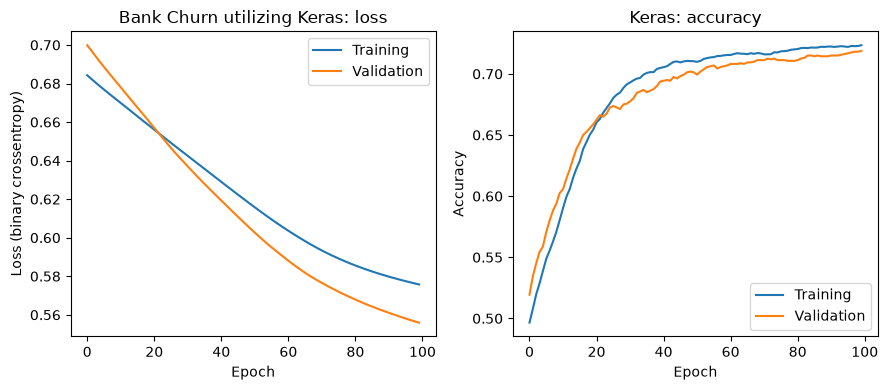

In [88]:
#1.4. Learning curves
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

axes[0].set_title('Bank Churn utilizing Keras: loss')
axes[0].plot(history.history['loss'], label='Training')
axes[0].plot(history.history['val_loss'], label='Validation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (binary crossentropy)')
axes[0].legend(loc='best')

axes[1].set_title('Keras: accuracy')
axes[1].plot(history.history['accuracy'], label='Training')
axes[1].plot(history.history['val_accuracy'], label='Validation')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend(loc='best')

plt.tight_layout()
plt.show()

###1.4. Test set evaluation

In [89]:
sequential_probs = model.predict(testing_df[features], verbose=0).flatten()
sequential_predictions = (sequential_probs >= 0.5).astype(int)
sequential_accuracy = accuracy_score(testing_df[label], sequential_predictions)

print(f'Optimized model accuracy on test set: {sequential_accuracy:.4f}')

Optimized model accuracy on test set: 0.7370


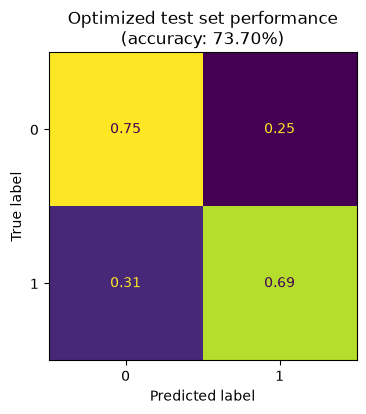

In [90]:
#1.4. Performance analysis - ConfusionMatrix
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(4, 4))

ax.set_title(f'Optimized test set performance\n(accuracy: {sequential_accuracy:.2%})')

disp = ConfusionMatrixDisplay.from_predictions(
    testing_df[label],
    sequential_predictions,
    normalize='true',
    ax=ax,
    colorbar=False
)